# Explore low-lewel data in HDF5 format using DL1DH

### Check paths and environments

In [1]:
# Where are we?
! pwd
# Do you want to print the log messages?
print_log = False

/Users/tmiener/deeplearning/iaa-advanced-neural-networks-2026/tutorials/ctlearn/notebooks


In [2]:
# Check for the versions of the core dependencies 
! conda list | grep ctlearn
! conda list | grep astropy
! conda list | grep ctapipe
! conda list | grep dl1-data-handler 
! conda list | grep keras
! conda list | grep tensorflow

# packages in environment at /Users/tmiener/miniforge3/envs/ctlearn:
ctlearn                          0.10.3               pypi_0              pypi
astropy                          8.0.0                pypi_0              pypi
astropy-iers-data                0.2026.6.22.1.23.34  pypi_0              pypi
ctapipe                          0.32.0               pypi_0              pypi
dl1-data-handler                 0.14.9               pypi_0              pypi
keras                            3.15.0               pypi_0              pypi
tensorflow                       2.21.0               pypi_0              pypi


In [3]:
# Set here correct path to downloaded test data of CTAO simulation.
DATA_DIR = "../../../../iaa-advanced-neural-networks-2026-ctao-data"
! du -h {DATA_DIR}/hdf5_merged/*

1.2G	../../../../iaa-advanced-neural-networks-2026-ctao-data/hdf5_merged/gamma_theta_16.087_az_108.090_runs1-2.r1.dl1.h5
1.3G	../../../../iaa-advanced-neural-networks-2026-ctao-data/hdf5_merged/gamma_theta_16.087_az_108.090_runs3-4.r1.dl1.h5
176M	../../../../iaa-advanced-neural-networks-2026-ctao-data/hdf5_merged/proton_theta_16.087_az_108.090_runs1-2.r1.dl1.h5
161M	../../../../iaa-advanced-neural-networks-2026-ctao-data/hdf5_merged/proton_theta_16.087_az_108.090_runs3-4.r1.dl1.h5
160M	../../../../iaa-advanced-neural-networks-2026-ctao-data/hdf5_merged/proton_theta_16.087_az_108.090_runs5-6.r1.dl1.h5


### Browsing through the HDF5 files via vitables
Use ViTables, a convenient GUI, to explore the data model.

In [4]:
#! conda run -n vitables vitables {DATA_DIR}/hdf5_merged/*

### Let's import some plotting libraries

In [5]:
from matplotlib import pyplot as plt
import matplotlib.animation as ani
from IPython.display import HTML
from traitlets.config.loader import Config

# For the DL1DH section
from dl1_data_handler.reader import DLImageReader, DLWaveformReader

# %matplotlib inline
plt.style.use("ggplot")

/Users/tmiener/miniforge3/envs/ctlearn/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Exploring the data files with DL1DH
Besides vitables we can also explore the data with the reading functionality of the DL1DH. This is a cruical part to inspect the previously performed data reduction through ctapipe. With this notebook one can spot corrupted data and ensure that the input provided to CTLearn's CNNs is correct.

In [6]:
LST1_gammafile = f"{DATA_DIR}/hdf5_merged/gamma_theta_16.087_az_108.090_runs1-2.r1.dl1.h5"
LST1_protonfile = f"{DATA_DIR}/hdf5_merged/proton_theta_16.087_az_108.090_runs1-2.r1.dl1.h5"

### Image reading
The basic functionality of reading images for a telescope operating in monoscopic mode. 

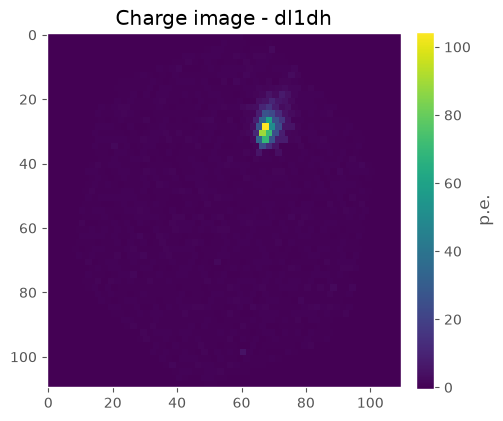

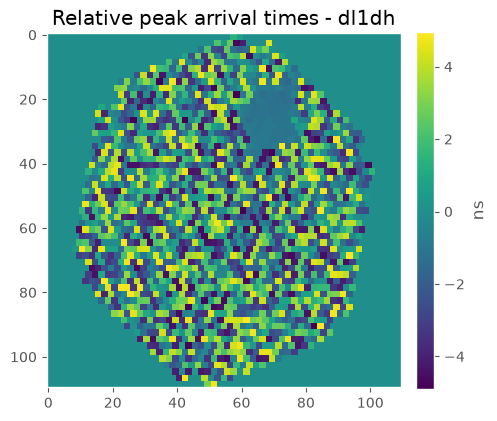

In [7]:
# Configuration settings
config = Config(
    {
        "DLImageReader": {
            "channels": ["image", "relative_peak_time"], # Options: ["image", "log_image", "cleaned_image", "log_cleaned_image", "peak_time", "relative_peak_time", "cleaned_peak_time", "cleaned_relative_peak_time"]
            "image_mapper_type": "OversamplingMapper", # Options: "AxialMapper", "BicubicMapper", "BilinearMapper", "NearestNeighborMapper", "OversamplingMapper", "RebinMapper"
        },
    },
)
# Init the DLImageReader class with the configuration above
mono_reader = DLImageReader(
    input_url_signal=[LST1_gammafile],
    input_url_background=[LST1_protonfile],
    config=config,
)
batch = mono_reader.generate_mono_batch(0)
if print_log:
    print(f"Print 'DLImageReader' object: {mono_reader}")
    print("Print the subarray information of a single LST (LST-1):")
    print(mono_reader.subarray.info())
    print("Print the simulation information:")
    print("\n".join(mono_reader.simulation_info.pformat(
        max_lines=-1,
        max_width=-1
    )))
    print(f"Number of signal (gamma) events: {mono_reader.n_signal_events}")
    print(f"Number of background (proton) events: {mono_reader.n_bkg_events}")
    print("Generate the first batch and print its content:")
    print("\n".join(batch.pformat(
        max_lines=-1,
        max_width=-1
    )))
# Plot the integrated image charges
charge_image = batch["features"][0, :, :, 0]
fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(charge_image, cmap="viridis")
ax.set_title("Charge image - dl1dh")
ax.grid(False)
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("p.e.", fontsize=12)
plt.show()
# Plot the relative peak arrival times
rel_peak_arrival_times = batch["features"][0, :, :, 1]
fig, ax = plt.subplots(figsize=(5, 5))
im_time = ax.imshow(rel_peak_arrival_times, cmap="viridis")
ax.set_title("Relative peak arrival times - dl1dh")
ax.grid(False)
cbar = fig.colorbar(im_time, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("ns", fontsize=12)
plt.show()


### Waveform reading
The basic functionality of reading waveforms for a telescope operating in monoscopic mode.

In [8]:
# Configuration settings
config = Config(
    {
        "DLWaveformReader": {
            "sequence_length": 40, # Number of waveform samples
            "sequence_position": "center", # Position of the sequence if 'sequence_length' is selected
            "cleaning_type": None, # Options: "image" (This would apply the DL1 image mask to the calibrated waveform)
            "image_mapper_type": "OversamplingMapper", # Options: "AxialMapper", "BicubicMapper", "BilinearMapper", "NearestNeighborMapper", "OversamplingMapper", "RebinMapper"
        },
    },
)
waveform_mono_reader = DLWaveformReader(
    input_url_signal=[LST1_gammafile],
    input_url_background=[LST1_protonfile],
    config=config,
)
batch = waveform_mono_reader.generate_mono_batch(0)
if print_log:
    print(f"Print 'DLWaveformReader' object: {waveform_mono_reader}")
    print("Print the subarray information of a single LST (LST-1):")
    print(waveform_mono_reader.subarray.info())
    print("Print the simulation information:")
    print("\n".join(waveform_mono_reader.simulation_info.pformat(
        max_lines=-1,
        max_width=-1
    )))
    print(f"Number of signal (gamma) events: {waveform_mono_reader.n_signal_events}")
    print(f"Number of background (proton) events: {waveform_mono_reader.n_bkg_events}")
    print("Generate the first batch and print its content:")
    print("\n".join(batch.pformat(
        max_lines=-1,
        max_width=-1
    )))
cal_waveforms = batch["features"][0]
# Create figure
fig, ax = plt.subplots(figsize=(5, 5))
# First frame
camera_screenshot = cal_waveforms[:, :, 0]
im = ax.imshow(
    camera_screenshot,
    cmap="viridis",
    interpolation="nearest"
)
ax.grid(False)
# Colorbar
cbar = fig.colorbar(
    im,
    ax=ax,
    fraction=0.046,
    pad=0.04
)
cbar.set_label("p.e.", fontsize=12)
# Title
time_text = ax.set_title(
    "Calibrated waveform (t = 0 ns) - dl1dh"
)
def update(frame):
    # Select the camera image for this sample
    camera_screenshot = cal_waveforms[:, :, frame]
    # Update image
    im.set_data(camera_screenshot)
    # Update color scale for this frame
    im.set_clim(
        camera_screenshot.min(),
        camera_screenshot.max()
    )
    # Update title
    time_text.set_text(
        f"Calibrated waveform (t = {frame} ns) - dl1dh"
    )
    return im, time_text
# Create animation
anim = ani.FuncAnimation(
    fig,
    update,
    frames=cal_waveforms.shape[-1],
    interval=500,   # milliseconds between frames
    blit=False
)
# Prevent the static matplotlib figure from also being displayed
plt.close(fig)
# Display animation in the notebook
HTML(anim.to_jshtml())
# Uncomment to save as GIF and show it your friends!
#anim.save("camera_waveform_dl1dh.gif", writer=ani.PillowWriter(fps=500))

### Stereo reading
The basic functionality of reading images for a telescope system operating in stereoscopic mode.

In [9]:
CTAO_gammafile = f"{DATA_DIR}/CTAO_test_data/gamma-diffuse_with_images_00.dl2.h5"
CTAO_protonfile = f"{DATA_DIR}/CTAO_test_data/proton_with_images_00.dl2.h5"

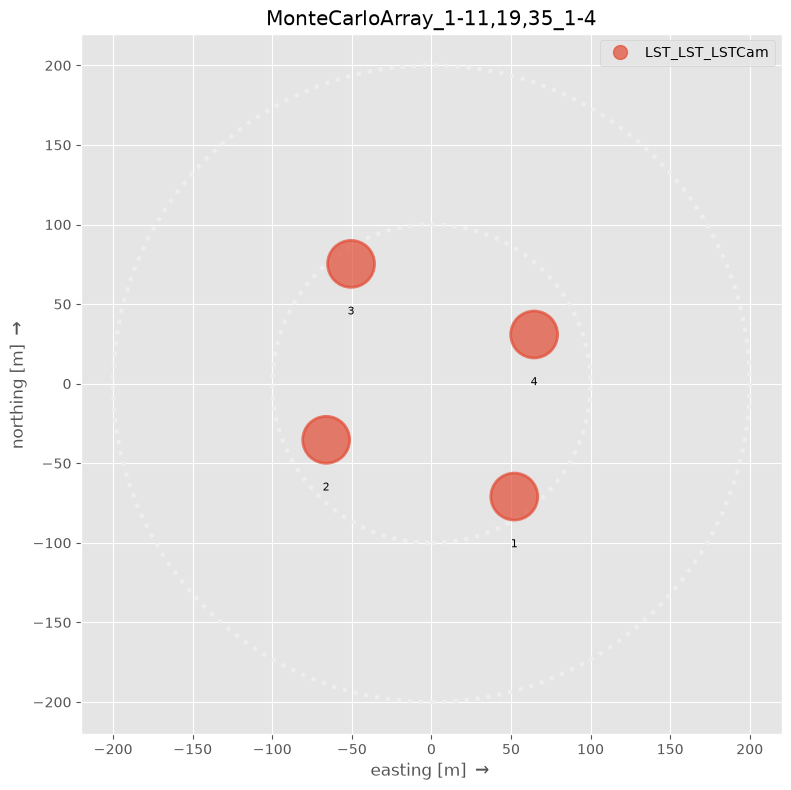

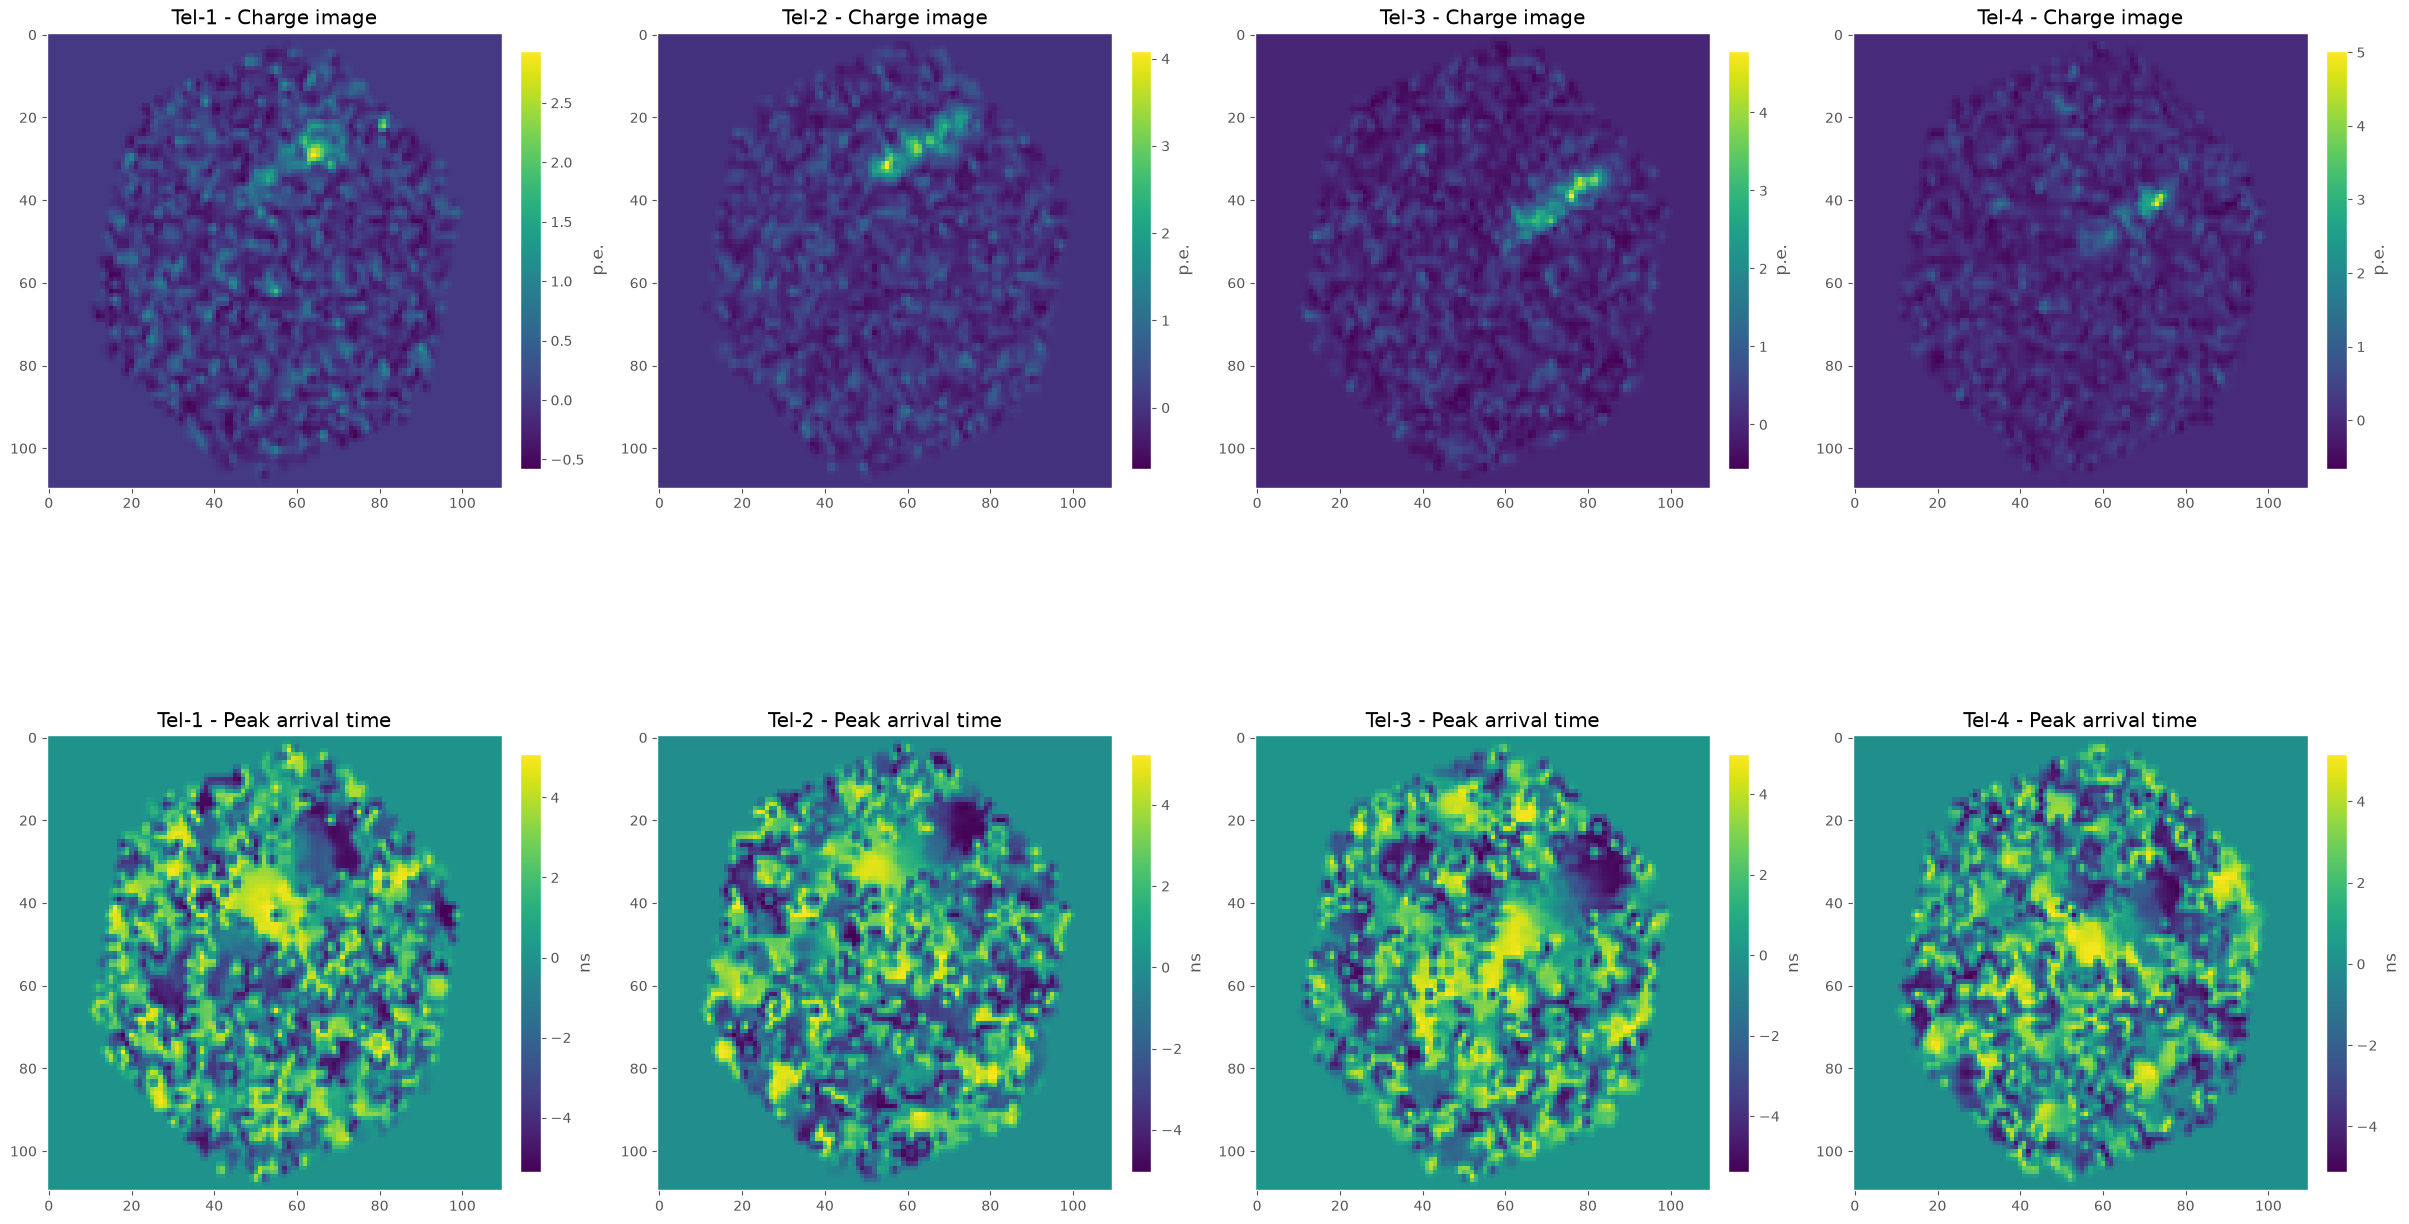

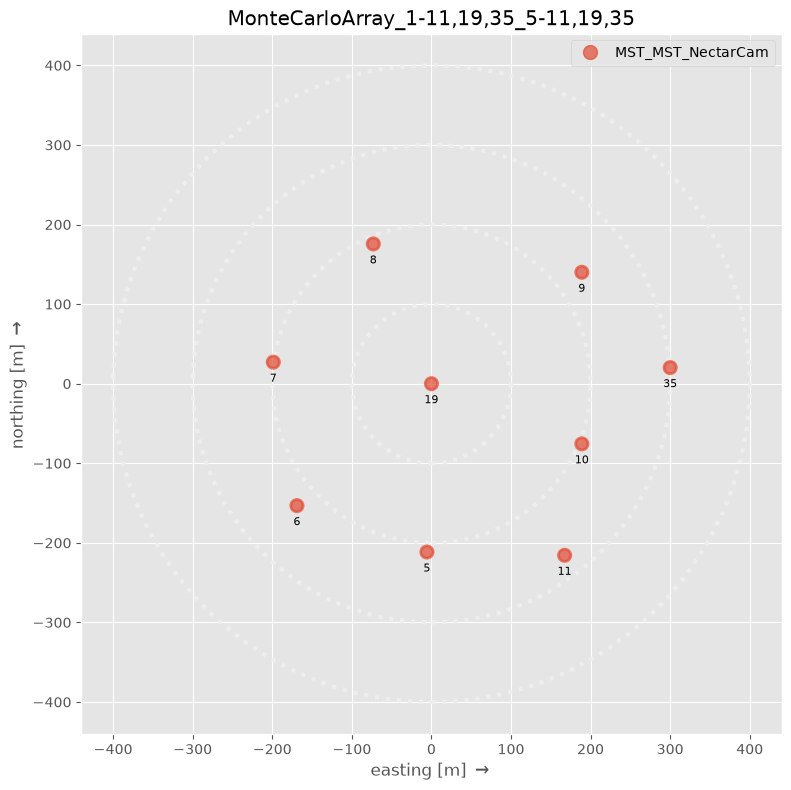

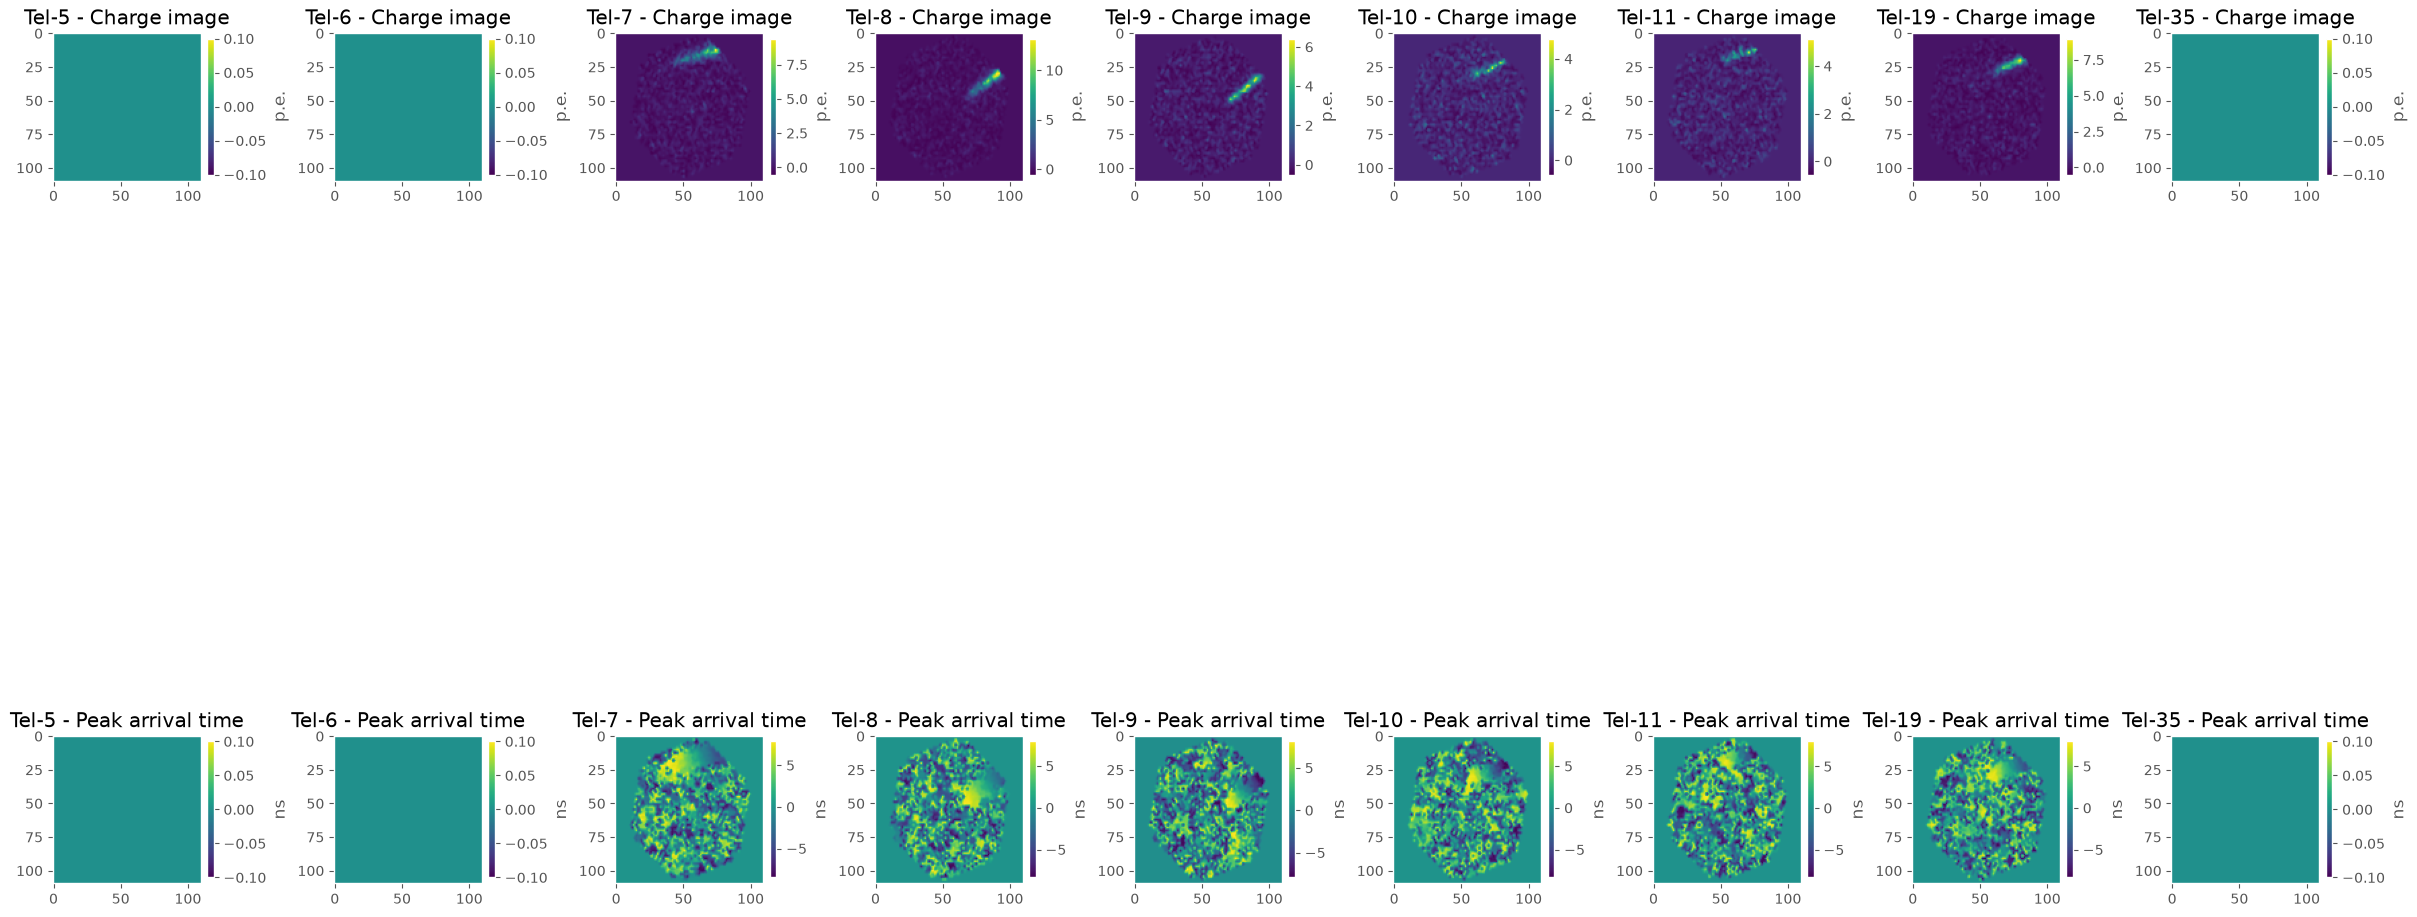

In [10]:
# Configuration settings
for tel_type in ["LST_LST_LSTCam", "MST_MST_NectarCam"]:
    min_tels = 4
    config = Config(
        {
            "TableQualityQuery": {
                "quality_criteria": [("> 0 phe", "hillas_intensity > 0")], # Very bright event
            },
            "DLImageReader": {
                "mode": "stereo",
                "allowed_tel_types": [tel_type], 
                "min_telescopes": min_tels,
                "channels": ["image", "relative_peak_time"], # Options: ["image", "log_image", "cleaned_image", "log_cleaned_image", "peak_time", "relative_peak_time", "cleaned_peak_time", "cleaned_relative_peak_time"]
                "image_mapper_type": "BilinearMapper", # Options: "AxialMapper", "BicubicMapper", "BilinearMapper", "NearestNeighborMapper", "OversamplingMapper", "RebinMapper"
            },
        },
    )
    # Init the DLImageReader class with the configuration above
    stereo_reader = DLImageReader(
        input_url_signal=[CTAO_gammafile],
        input_url_background=[CTAO_protonfile],
        config=config,
    )
    stereo_reader.subarray.peek()
    batch = stereo_reader.generate_stereo_batch(0)
    if print_log:
        print(f"Print 'DLImageReader' object: {stereo_reader}")
        print("Print the subarray information:")
        print(stereo_reader.subarray.info())
        print("Print the simulation information:")
        print("\n".join(stereo_reader.simulation_info.pformat(
            max_lines=-1,
            max_width=-1
        )))
        print(f"Number of signal (gamma) events: {stereo_reader.n_signal_events}")
        print(f"Number of background (proton) events: {stereo_reader.n_bkg_events}")
        print("Generate the first batch and print its content:")
        print("\n".join(batch.pformat(
            max_lines=-1,
            max_width=-1
        )))
    fig, axes = plt.subplots(
        2, len(batch["tel_id"]),
        figsize=(24, 14),
        constrained_layout=True
    )
    for t, tel_id in enumerate(batch["tel_id"]):
        # Integrated image charges
        charge_image = batch["features"][t, :, :, 0]
        im_charge = axes[0, t].imshow(
            charge_image,
            cmap="viridis"
        )
        axes[0, t].set_title(
            f"Tel-{tel_id} - Charge image"
        )
        axes[0, t].grid(False)
        cbar_charge = fig.colorbar(
            im_charge,
            ax=axes[0, t],
            fraction=0.046,
            pad=0.04
        )
        cbar_charge.set_label("p.e.", fontsize=12)
        # Relative peak arrival times
        rel_peak_arrival_times = batch["features"][t, :, :, 1]
        im_time = axes[1, t].imshow(
            rel_peak_arrival_times,
            cmap="viridis"
        )
        axes[1, t].set_title(
            f"Tel-{tel_id} - Peak arrival time"
        )
        axes[1, t].grid(False)
        cbar_time = fig.colorbar(
            im_time,
            ax=axes[1, t],
            fraction=0.046,
            pad=0.04
        )
        cbar_time.set_label("ns", fontsize=12)
    plt.show()